In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Настройка отображения графиков
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [19]:
import pandas as pd
from google.colab import drive

# 1. Подключаем Google Диск (появится запрос на разрешение доступа)
drive.mount('/content/drive')

# 2. Задаем правильный путь к файлу на диске
file_path = '/content/drive/MyDrive/synthetic_dna_dataset.csv'

# 3. Загружаем данные в таблицу (DataFrame)
df = pd.read_csv(file_path)

# 4. Выводим размер таблицы
print(f"Размер таблицы: {df.shape}")

# 5. Показываем первые 5 строк
print("\nПервые 5 строк:")
print(df.head())

# 6. Выводим список названий всех столбцов
print("\nСписок столбцов:")
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Размер таблицы: (3000, 13)

Первые 5 строк:
  Sample_ID                                           Sequence  GC_Content  \
0  SAMPLE_1  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...        50.0   
1  SAMPLE_2  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...        45.0   
2  SAMPLE_3  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...        51.0   
3  SAMPLE_4  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...        55.0   
4  SAMPLE_5  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...        46.0   

   AT_Content  Sequence_Length  Num_A  Num_T  Num_C  Num_G  kmer_3_freq  \
0        50.0              100     22     28     19     31        0.986   
1        55.0              100     27     28     22     23        0.486   
2        49.0              100     26     23     30     21        0.367   
3        45.0              100     28     17     23     32

In [20]:
import pandas as pd
from google.colab import drive

# 1. Подключаем Google Диск
drive.mount('/content/drive')

# 2. Указываем точный путь к файлу на диске
# (Предполагаем, что файл лежит в корне твоего Диска "MyDrive")
file_path = '/content/drive/MyDrive/synthetic_dna_dataset.csv'

# 3. Загружаем данные
df = pd.read_csv(file_path)

# 4. Проверяем, что все получилось
print(f"Размер таблицы: {df.shape}")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Размер таблицы: (3000, 13)
  Sample_ID                                           Sequence  GC_Content  \
0  SAMPLE_1  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...        50.0   
1  SAMPLE_2  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...        45.0   
2  SAMPLE_3  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...        51.0   
3  SAMPLE_4  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...        55.0   
4  SAMPLE_5  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...        46.0   

   AT_Content  Sequence_Length  Num_A  Num_T  Num_C  Num_G  kmer_3_freq  \
0        50.0              100     22     28     19     31        0.986   
1        55.0              100     27     28     22     23        0.486   
2        49.0              100     26     23     30     21        0.367   
3        45.0              100     28     17     23     32        0.404   


In [21]:
# 1. Общая информация о таблице (типы, количество ненулевых значений)
print("--- Общая информация (df.info()) ---")
df.info()

print("\n--- Типы данных каждого столбца (df.dtypes) ---")
print(df.dtypes)

# 2. Разделение на числовые и нечисловые столбцы
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nЧисловые столбцы ({len(numeric_cols)}): {numeric_cols}")
print(f"Текстовые/Категориальные столбцы ({len(categorical_cols)}): {categorical_cols}")

# 3. Поиск потенциальных дат (если они есть)
date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
if not date_cols:
    # Дополнительная проверка: иногда даты хранятся как текст
    potential_date_cols = [col for col in categorical_cols if 'date' in col.lower() or 'time' in col.lower()]
    print(f"\nСтолбцы с типом datetime: {date_cols}")
    print(f"Потенциальные текстовые столбцы с датами (по названию): {potential_date_cols}")
else:
    print(f"\nНайдены столбцы с типом datetime: {date_cols}")

--- Общая информация (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   object 
 1   Sequence         3000 non-null   object 
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   object 
 12  Disease_Risk     3000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 304.8+ KB

--- Типы данных каждого столбца (df.dtypes) ---
Sample_ID           object
Sequence            object

In [22]:
# 1. Количество пропусков по каждому столбцу
missing_counts = df.isnull().sum()

# 2. Доля пропусков в процентах
missing_percents = (df.isnull().sum() / len(df) * 100).round(2)

# Создаем сводную таблицу для наглядности
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent (%)': missing_percents
})

# 3. Выводим только те столбцы, где есть пропуски
print("--- Столбцы с пропусками ---")
print(missing_info[missing_info['Missing Count'] > 0])

# 4. Общее количество строк с хотя бы одним пропуском
rows_with_missing = df[df.isnull().any(axis=1)].shape[0]
print(f"\nВсего строк с пропусками: {rows_with_missing} из {len(df)} ({(rows_with_missing/len(df)*100):.2f}%)")

--- Столбцы с пропусками ---
Empty DataFrame
Columns: [Missing Count, Missing Percent (%)]
Index: []

Всего строк с пропусками: 0 из 3000 (0.00%)


In [23]:
# 1. Подсчет полных дубликатов строк
num_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {num_duplicates}")

# 2. Если есть дубликаты, показываем примеры
if num_duplicates > 0:
    print("\nПримеры дублирующихся строк:")
    # Показываем первые 5 строк, которые являются дубликатами
    print(df[df.duplicated()].head())
else:
    print("\nПолных дубликатов строк не найдено.")

# 3. Проверка уникальности идентификатора (Sample_ID)
unique_ids = df['Sample_ID'].nunique()
total_rows = len(df)
print(f"\nВсего строк: {total_rows}")
print(f"Уникальных Sample_ID: {unique_ids}")

if unique_ids < total_rows:
    print("⚠️ Внимание: количество уникальных ID меньше количества строк. Есть дубликаты по ключевому полю!")
    # Показываем примеры повторяющихся ID
    print("\nПримеры повторяющихся ID:")
    print(df[df['Sample_ID'].duplicated(keep=False)].sort_values('Sample_ID').head(10))

Количество полных дубликатов строк: 0

Полных дубликатов строк не найдено.

Всего строк: 3000
Уникальных Sample_ID: 3000


In [25]:
import pandas as pd

drive.mount('/content/drive')

# 2. Указываем точный путь к файлу на диске
# (Предполагаем, что файл лежит в корне твоего Диска "MyDrive")
file_path = '/content/drive/MyDrive/synthetic_dna_dataset.csv'

# 3. Загружаем данные
df = pd.read_csv(file_path)

print("--- 1. Базовая статистика по числовым столбцам (describe) ---")
print(df.describe())

print("\n--- 2. Минимальные и максимальные значения ---")
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

print("\n--- 3. Уникальные значения в категориальных столбцах ---")
categorical_cols = ['Class_Label', 'Disease_Risk', 'Mutation_Flag']
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} уникальных): {unique_vals}")

print("\n--- 4. Поиск потенциально некорректных значений ---")
# Проверка на отрицательные значения в полях, где их быть не должно (количества, длины, проценты)
cols_to_check_non_negative = ['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']
for col in cols_to_check_non_negative:
    if (df[col] < 0).any():
        count_neg = (df[col] < 0).sum()
        print(f"⚠️ В столбце '{col}' найдено {count_neg} отрицательных значений!")
    else:
        print(f"✅ Столбец '{col}': отрицательных значений нет.")

# Проверка GC + AT на равенство ~100
gc_at_sum = df['GC_Content'] + df['AT_Content']
if not ((gc_at_sum >= 99.9) & (gc_at_sum <= 100.1)).all():
    print("⚠️ Найдены строки, где сумма GC_Content и AT_Content не равна 100%.")
    print(df[~((gc_at_sum >= 99.9) & (gc_at_sum <= 100.1))][['GC_Content', 'AT_Content']].head())
else:
    print("✅ Сумма GC_Content и AT_Content везде корректна (~100%).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 1. Базовая статистика по числовым столбцам (describe) ---
        GC_Content   AT_Content  Sequence_Length        Num_A        Num_T  \
count  3000.000000  3000.000000           3000.0  3000.000000  3000.000000   
mean     50.120000    49.880000            100.0    24.950667    24.929333   
std       5.062688     5.062688              0.0     4.317458     4.317702   
min      34.000000    34.000000            100.0    11.000000     9.000000   
25%      47.000000    47.000000            100.0    22.000000    22.000000   
50%      50.000000    50.000000            100.0    25.000000    25.000000   
75%      53.000000    53.000000            100.0    28.000000    28.000000   
max      66.000000    66.000000            100.0    40.000000    42.000000   

             Num_C        Num_G  kmer_3_freq  Mutation_Flag  
count  3000.000000  3000.000000  3000.000000

In [26]:
import pandas as pd

# 1. Создаем копию исходного датафрейма для работы
df_clean = df.copy()

print(f"Исходный размер: {df.shape}")

# 2. Приводим категориальные столбцы к типу 'category' для оптимизации памяти и скорости группировок
categorical_cols = ['Class_Label', 'Disease_Risk']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

# 3. Удаляем полные дубликаты строк (если они есть)
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_rows - len(df_clean)
print(f"Удалено полных дубликатов: {duplicates_removed}")

# 4. Валидация суммы GC + AT (должна быть близка к 100%)
# Создаем маску для строк, где сумма выходит за пределы 99-101%
sum_check = df_clean['GC_Content'] + df_clean['AT_Content']
invalid_sum_mask = (sum_check < 99) | (sum_check > 101)
invalid_sums_count = invalid_sum_mask.sum()

if invalid_sums_count > 0:
    print(f"Найдено строк с некорректной суммой процентов: {invalid_sums_count}. Они будут удалены.")
    df_clean = df_clean[~invalid_sum_mask]
else:
    print("Все строки прошли проверку суммы GC + AT.")

# 5. Проверка на отрицательные значения в ключевых числовых полях
numeric_cols_to_check = ['GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'Sequence_Length']
negative_mask = pd.Series([False] * len(df_clean))

for col in numeric_cols_to_check:
    negative_mask = negative_mask | (df_clean[col] < 0)

negatives_count = negative_mask.sum()
if negatives_count > 0:
    print(f"Найдено строк с отрицательными значениями: {negatives_count}. Они будут удалены.")
    df_clean = df_clean[~negative_mask]
else:
    print("Отрицательных значений в ключевых полях не найдено.")

# 6. Финальная проверка пропусков и удаление строк, если они появились
missing_final = df_clean.isnull().sum().sum()
if missing_final > 0:
    print(f"Найдено пропусков: {missing_final}. Строки с пропусками удаляются.")
    df_clean = df_clean.dropna()
else:
    print("Пропусков не найдено.")

# 7. Итоговый отчет по очистке
print("\n--- Итоги очистки ---")
print(f"Размер исходной таблицы (df): {df.shape}")
print(f"Размер очищенной таблицы (df_clean): {df_clean.shape}")
print(f"Всего удалено строк: {df.shape[0] - df_clean.shape[0]}")

# 8. Повторная проверка качества df_clean
print("\n--- Проверка качества df_clean ---")
print("Пропуски по столбцам:")
print(df_clean.isnull().sum())
print(f"\nПолные дубликаты: {df_clean.duplicated().sum()}")
print("\nТипы данных:")
print(df_clean.dtypes)

Исходный размер: (3000, 13)
Удалено полных дубликатов: 0
Все строки прошли проверку суммы GC + AT.
Отрицательных значений в ключевых полях не найдено.
Пропусков не найдено.

--- Итоги очистки ---
Размер исходной таблицы (df): (3000, 13)
Размер очищенной таблицы (df_clean): (3000, 13)
Всего удалено строк: 0

--- Проверка качества df_clean ---
Пропуски по столбцам:
Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
dtype: int64

Полные дубликаты: 0

Типы данных:
Sample_ID            object
Sequence             object
GC_Content          float64
AT_Content          float64
Sequence_Length       int64
Num_A                 int64
Num_T                 int64
Num_C                 int64
Num_G                 int64
kmer_3_freq         float64
Mutation_Flag         int64
Class

In [27]:
# 1. Создание признака суммы процентов для валидации
df_clean['GC_AT_Sum'] = df_clean['GC_Content'] + df_clean['AT_Content']

# 2. Создание числового эквивалента уровня риска (для удобства сортировки)
risk_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Risk_Level_Num'] = df_clean['Disease_Risk'].map(risk_mapping)

# Проверка результата
print("Новые столбцы добавлены:")
print(df_clean[['GC_Content', 'AT_Content', 'GC_AT_Sum', 'Disease_Risk', 'Risk_Level_Num']].head())

Новые столбцы добавлены:
   GC_Content  AT_Content  GC_AT_Sum Disease_Risk Risk_Level_Num
0        50.0        50.0      100.0         High              3
1        45.0        55.0      100.0       Medium              2
2        51.0        49.0      100.0          Low              1
3        55.0        45.0      100.0       Medium              2
4        46.0        54.0      100.0         High              3


In [28]:
import pandas as pd

# 1. Размер очищенной таблицы
print(f"Размер df_clean: {df_clean.shape}")

# 2. Типы данных
print("\nТипы данных:")
print(df_clean.dtypes)

# 3. Количество уникальных значений по каждому столбцу
print("\nКоличество уникальных значений:")
print(df_clean.nunique())

# 4. Статистика по числовым столбцам
print("\nОписательная статистика (числовые):")
numeric_cols = df_clean.select_dtypes(include=['number']).columns
print(df_clean[numeric_cols].describe())

# 5. Статистика по категориальным столбцам
print("\nОписательная статистика (категориальные):")
categorical_cols = df_clean.select_dtypes(include=['category', 'object']).columns
# Для категорий describe() покажет count, unique, top и freq
print(df_clean[categorical_cols].describe())

Размер df_clean: (3000, 15)

Типы данных:
Sample_ID            object
Sequence             object
GC_Content          float64
AT_Content          float64
Sequence_Length       int64
Num_A                 int64
Num_T                 int64
Num_C                 int64
Num_G                 int64
kmer_3_freq         float64
Mutation_Flag         int64
Class_Label        category
Disease_Risk       category
GC_AT_Sum           float64
Risk_Level_Num     category
dtype: object

Количество уникальных значений:
Sample_ID          3000
Sequence           3000
GC_Content           33
AT_Content           33
Sequence_Length       1
Num_A                30
Num_T                32
Num_C                32
Num_G                30
kmer_3_freq         872
Mutation_Flag         2
Class_Label           4
Disease_Risk          3
GC_AT_Sum             1
Risk_Level_Num        3
dtype: int64

Описательная статистика (числовые):
        GC_Content   AT_Content  Sequence_Length        Num_A        Num_T  \
cou

In [29]:
# Количество уникальных значений
print(f"Уникальных типов организмов: {df_clean['Class_Label'].nunique()}")

# Топ-10 самых частых значений (в данном случае их всего 4)
class_counts = df_clean['Class_Label'].value_counts()
print("\nРаспределение по типам организмов:")
print(class_counts)

# Доля каждой категории
class_percents = df_clean['Class_Label'].value_counts(normalize=True) * 100
print("\nДоля каждого типа (%):")
print(class_percents.round(2))

Уникальных типов организмов: 4

Распределение по типам организмов:
Class_Label
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64

Доля каждого типа (%):
Class_Label
Bacteria    25.37
Human       24.97
Plant       24.90
Virus       24.77
Name: proportion, dtype: float64


In [30]:
# Количество уникальных значений
print(f"Уникальных уровней риска: {df_clean['Disease_Risk'].nunique()}")

# Топ-10 самых частых значений
risk_counts = df_clean['Disease_Risk'].value_counts()
print("\nРаспределение по уровню риска:")
print(risk_counts)

# Доля каждой категории
risk_percents = df_clean['Disease_Risk'].value_counts(normalize=True) * 100
print("\nДоля каждого уровня риска (%):")
print(risk_percents.round(2))

Уникальных уровней риска: 3

Распределение по уровню риска:
Disease_Risk
High      1046
Low        978
Medium     976
Name: count, dtype: int64

Доля каждого уровня риска (%):
Disease_Risk
High      34.87
Low       32.60
Medium    32.53
Name: proportion, dtype: float64


In [31]:
# Количество уникальных значений
print(f"Уникальных значений флага мутации: {df_clean['Mutation_Flag'].nunique()}")

# Распределение
mutation_counts = df_clean['Mutation_Flag'].value_counts()
print("\nРаспределение мутаций (0 - нет, 1 - есть):")
print(mutation_counts)

# Доля
mutation_percents = df_clean['Mutation_Flag'].value_counts(normalize=True) * 100
print("\nДоля образцов с мутацией (%):")
print(mutation_percents.round(2))

Уникальных значений флага мутации: 2

Распределение мутаций (0 - нет, 1 - есть):
Mutation_Flag
0    1510
1    1490
Name: count, dtype: int64

Доля образцов с мутацией (%):
Mutation_Flag
0    50.33
1    49.67
Name: proportion, dtype: float64


In [32]:
# Выбираем основной числовой признак
col = 'GC_Content'

print(f"--- Статистика по столбцу: {col} ---")

# Базовые метрики
mean_val = df_clean[col].mean()
median_val = df_clean[col].median()
min_val = df_clean[col].min()
max_val = df_clean[col].max()

# Квартили
q25 = df_clean[col].quantile(0.25)
q75 = df_clean[col].quantile(0.75)

# Пропуски
missing_count = df_clean[col].isnull().sum()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Медиана: {median_val:.2f}")
print(f"Минимум: {min_val:.2f}")
print(f"Максимум: {max_val:.2f}")
print(f"25-й процентиль (Q1): {q25:.2f}")
print(f"75-й процентиль (Q3): {q75:.2f}")
print(f"Количество пропусков: {missing_count}")

# Интерпретация размаха
iqr = q75 - q25
print(f"\nИнтерквартильный размах (IQR): {iqr:.2f}")

--- Статистика по столбцу: GC_Content ---
Среднее значение: 50.12
Медиана: 50.00
Минимум: 34.00
Максимум: 66.00
25-й процентиль (Q1): 47.00
75-й процентиль (Q3): 53.00
Количество пропусков: 0

Интерквартильный размах (IQR): 6.00


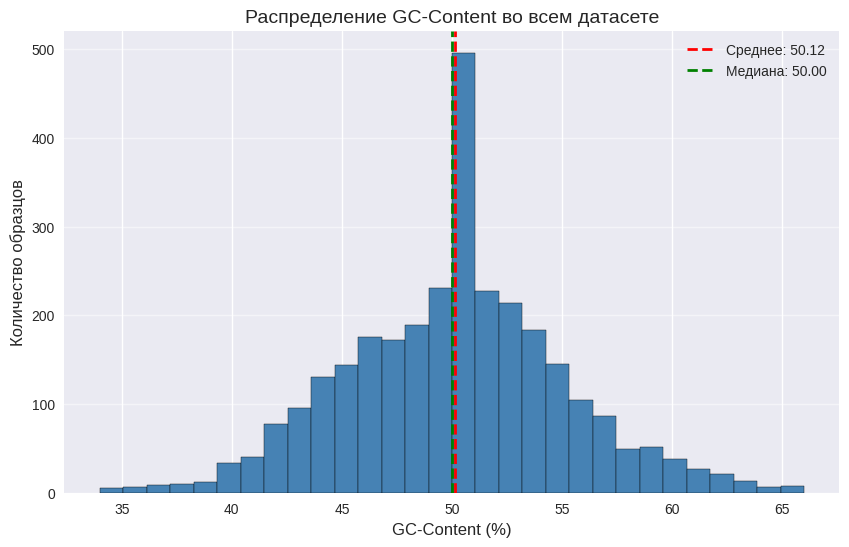

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Настройка размера графика
plt.figure(figsize=(10, 6))

# Построение гистограммы
plt.hist(df_clean['GC_Content'], bins=30, color='steelblue', edgecolor='black')

# Добавление линий среднего и медианы
mean_val = df_clean['GC_Content'].mean()
median_val = df_clean['GC_Content'].median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {median_val:.2f}')

# Оформление
plt.title('Распределение GC-Content во всем датасете', fontsize=14)
plt.xlabel('GC-Content (%)', fontsize=12)
plt.ylabel('Количество образцов', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)

# Отображение
plt.show()

/tmp/ipykernel_1261/4193401764.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_stats = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'std']).reset_index()


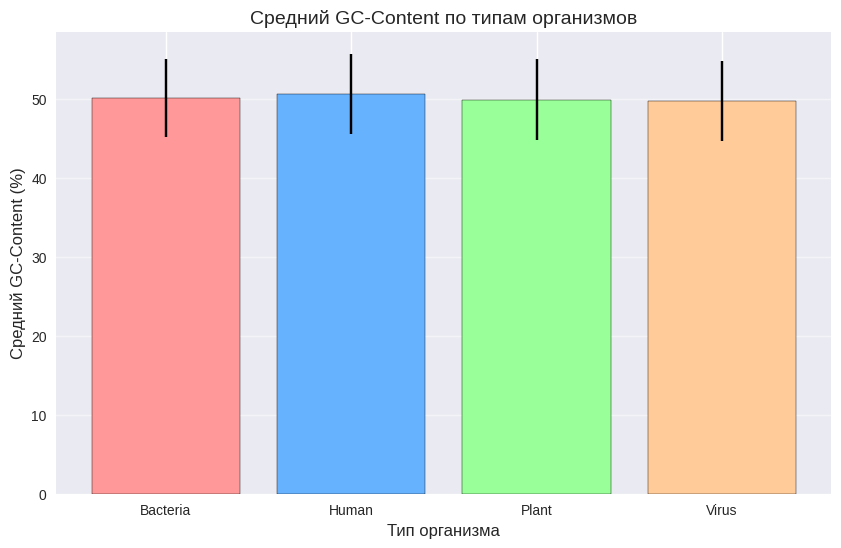

In [34]:
# Расчет средних значений и стандартного отклонения
class_stats = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

# Построение столбчатой диаграммы с error bars (стандартное отклонение)
plt.bar(class_stats['Class_Label'], class_stats['mean'], yerr=class_stats['std'],
        capsize=5, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'], edgecolor='black')

# Оформление
plt.title('Средний GC-Content по типам организмов', fontsize=14)
plt.xlabel('Тип организма', fontsize=12)
plt.ylabel('Средний GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()

/tmp/ipykernel_1261/1556995693.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_for_plot, labels=df_clean['Class_Label'].unique(), patch_artist=True)


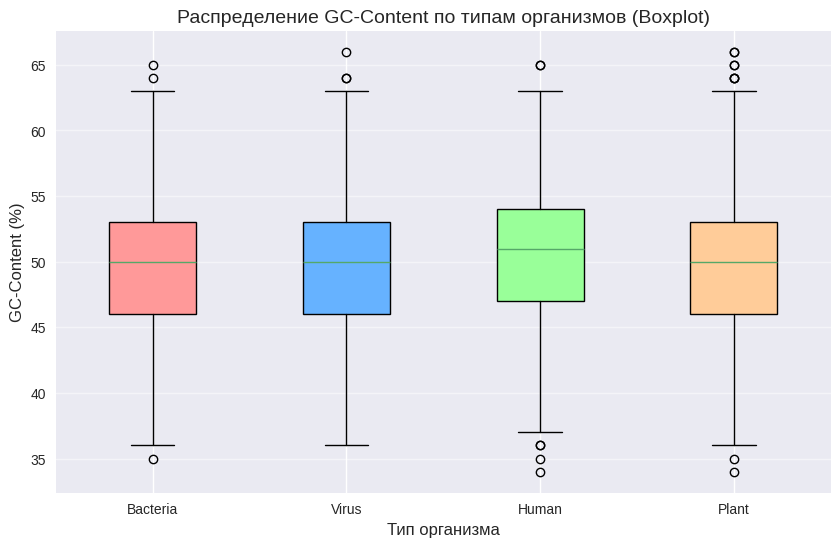

In [35]:
plt.figure(figsize=(10, 6))

# Подготовка данных для boxplot
data_for_plot = [df_clean[df_clean['Class_Label'] == cls]['GC_Content'].values for cls in df_clean['Class_Label'].unique()]

# Построение boxplot
bp = plt.boxplot(data_for_plot, labels=df_clean['Class_Label'].unique(), patch_artist=True)

# Раскраска ящиков для наглядности
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Оформление
plt.title('Распределение GC-Content по типам организмов (Boxplot)', fontsize=14)
plt.xlabel('Тип организма', fontsize=12)
plt.ylabel('GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()

/tmp/ipykernel_1261/1757370771.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_risk = plt.boxplot(data_risk, labels=risk_levels, patch_artist=True)


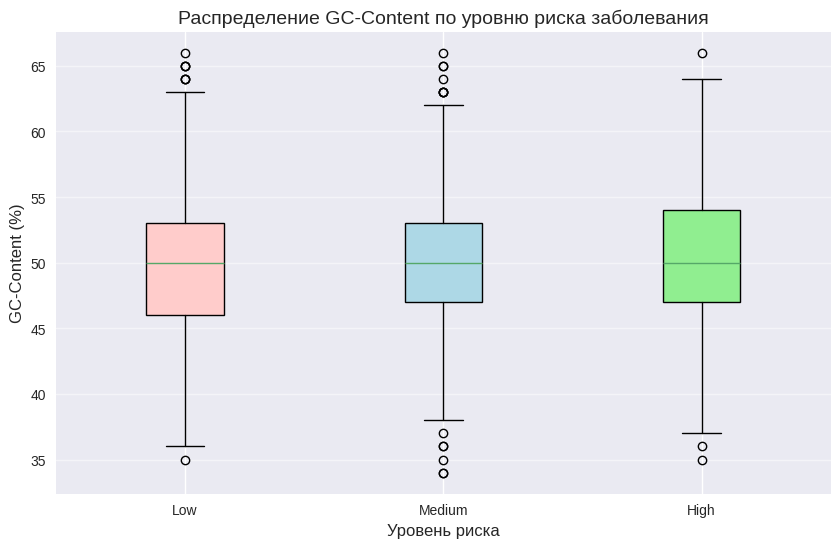

In [36]:
plt.figure(figsize=(10, 6))

# Подготовка данных
risk_levels = ['Low', 'Medium', 'High']
data_risk = [df_clean[df_clean['Disease_Risk'] == level]['GC_Content'].values for level in risk_levels]

# Построение boxplot для уровней риска
bp_risk = plt.boxplot(data_risk, labels=risk_levels, patch_artist=True)

colors_risk = ['#ffcccb', '#add8e6', '#90ee90']
for patch, color in zip(bp_risk['boxes'], colors_risk):
    patch.set_facecolor(color)

# Оформление
plt.title('Распределение GC-Content по уровню риска заболевания', fontsize=14)
plt.xlabel('Уровень риска', fontsize=12)
plt.ylabel('GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()

In [37]:
import pandas as pd

# 1. Среднее и медиана по типам организмов
print("--- 1. Статистика GC-Content по типам организмов ---")
stats_by_class = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'median']).round(2)
print(stats_by_class)

# 2. Стандартное отклонение (разброс) по типам организмов
print("\n--- 2. Разброс значений (Std) по типам организмов ---")
std_by_class = df_clean.groupby('Class_Label')['GC_Content'].std().round(2)
print(std_by_class)

# 3. Среднее и медиана по уровню риска
print("\n--- 3. Статистика GC-Content по уровню риска ---")
stats_by_risk = df_clean.groupby('Disease_Risk')['GC_Content'].agg(['mean', 'median']).round(2)
print(stats_by_risk)

# 4. Кросс-таблица: Средний GC-Content для комбинаций Организм/Риск
print("\n--- 4. Сводная таблица: Средний GC-Content (Организм x Риск) ---")
pivot_table = df_clean.pivot_table(values='GC_Content', index='Class_Label', columns='Disease_Risk', aggfunc='mean').round(2)
print(pivot_table)

--- 1. Статистика GC-Content по типам организмов ---
              mean  median
Class_Label               
Bacteria     50.14    50.0
Human        50.66    51.0
Plant        49.92    50.0
Virus        49.75    50.0

--- 2. Разброс значений (Std) по типам организмов ---
Class_Label
Bacteria    4.98
Human       5.08
Plant       5.10
Virus       5.05
Name: GC_Content, dtype: float64

--- 3. Статистика GC-Content по уровню риска ---
               mean  median
Disease_Risk               
High          50.36    50.0
Low           49.77    50.0
Medium        50.21    50.0

--- 4. Сводная таблица: Средний GC-Content (Организм x Риск) ---
Disease_Risk   High    Low  Medium
Class_Label                       
Bacteria      50.16  49.51   50.67
Human         50.94  50.37   50.66
Plant         50.07  49.62   50.05
Virus         50.30  49.59   49.35


/tmp/ipykernel_1261/770345809.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_by_class = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'median']).round(2)
/tmp/ipykernel_1261/770345809.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_by_class = df_clean.groupby('Class_Label')['GC_Content'].std().round(2)
/tmp/ipykernel_1261/770345809.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat

In [ ]:
# Группировка по типу организма с расчетом среднего, медианы и количества наблюдений
comparison = df_clean.groupby('Class_Label')['GC_Content'].agg(
    mean='mean',
    median='median',
    count='count'
).round(2)

# Сортировка по среднему значению (по убыванию)
comparison_sorted = comparison.sort_values(by='mean', ascending=False)

# Вывод результата
print("Сравнение GC-Content по типам организмов:")
print(comparison_sorted)

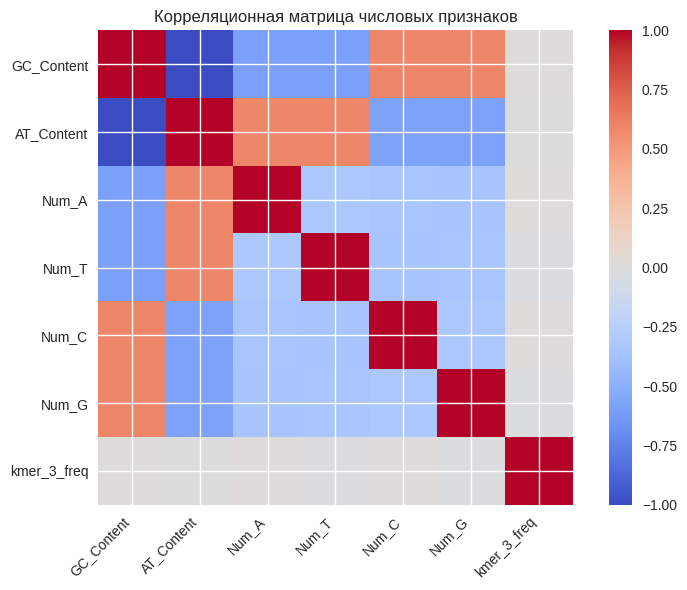

--- Топ-5 самых сильных корреляций ---
AT_Content   Num_T          0.586319
Num_T        AT_Content     0.586319
AT_Content   Num_A          0.586256
Num_A        AT_Content     0.586256
Num_C        GC_Content     0.585878
GC_Content   Num_C          0.585878
             Num_G          0.580809
Num_G        GC_Content     0.580809
Num_A        kmer_3_freq    0.014714
kmer_3_freq  Num_A          0.014714
dtype: float64


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Выбираем только числовые столбцы для анализа
numeric_cols = df_clean.select_dtypes(include=['number']).columns

# Исключаем идентификаторы или константы, если они есть (например, Sample_ID не числовой, но Sequence_Length может быть константой)
# В данном случае оставим все числовые, так как нам интересно увидеть даже тривиальные связи
cols_to_corr = ['GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']

# 2. Строим корреляционную матрицу
corr_matrix = df_clean[cols_to_corr].corr()

# 3. Визуализируем матрицу (Heatmap)
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(cols_to_corr)), cols_to_corr, rotation=45, ha='right')
plt.yticks(range(len(cols_to_corr)), cols_to_corr)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

# 4. Выводим пары с самой сильной корреляцией (по модулю)
# Преобразуем матрицу в удобный формат для поиска максимумов
corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)

# Убираем единичные корреляции признака с самим собой и дубликаты
unique_pairs = corr_pairs[(corr_pairs < 1.0)]

print("--- Топ-5 самых сильных корреляций ---")
print(unique_pairs.head(10)) # Показываем топ, так как сильные связи будут парными

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Группировка по типу организма с расчетом среднего, медианы и количества
stats_by_class = df_clean.groupby('Class_Label')['GC_Content'].agg(
    mean='mean',
    median='median',
    count='count'
).round(2)

print("Статистика GC-Content по типам организмов:")
print(stats_by_class)

Статистика GC-Content по типам организмов:
              mean  median  count
Class_Label                      
Bacteria     50.14    50.0    761
Human        50.66    51.0    749
Plant        49.92    50.0    747
Virus        49.75    50.0    743


/tmp/ipykernel_1261/3579367045.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_by_class = df_clean.groupby('Class_Label')['GC_Content'].agg(


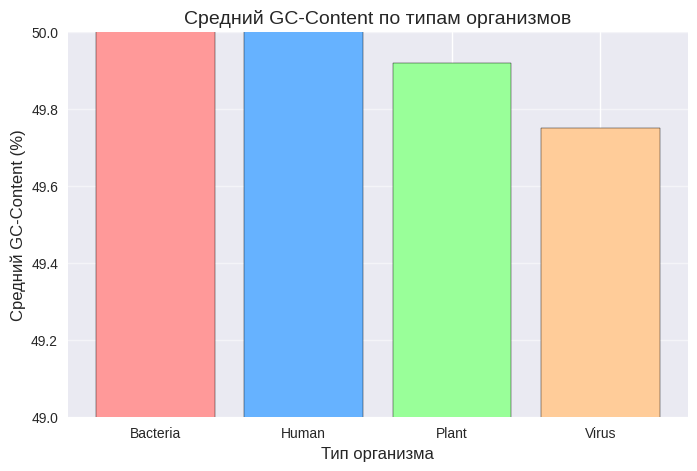

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(stats_by_class.index, stats_by_class['mean'], color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'], edgecolor='black')
plt.title('Средний GC-Content по типам организмов', fontsize=14)
plt.xlabel('Тип организма', fontsize=12)
plt.ylabel('Средний GC-Content (%)', fontsize=12)
plt.ylim(49, 50) # Сужаем ось Y, чтобы увидеть разницу
plt.grid(axis='y', alpha=0.5)
plt.show()

Матрица корреляций:
             GC_Content  AT_Content  Num_A  Num_T  Num_C  Num_G  kmer_3_freq
GC_Content         1.00       -1.00  -0.59  -0.59   0.59   0.58         0.00
AT_Content        -1.00        1.00   0.59   0.59  -0.59  -0.58        -0.00
Num_A             -0.59        0.59   1.00  -0.31  -0.34  -0.34         0.01
Num_T             -0.59        0.59  -0.31   1.00  -0.35  -0.34        -0.02
Num_C              0.59       -0.59  -0.34  -0.35   1.00  -0.32         0.01
Num_G              0.58       -0.58  -0.34  -0.34  -0.32   1.00        -0.01
kmer_3_freq        0.00       -0.00   0.01  -0.02   0.01  -0.01         1.00


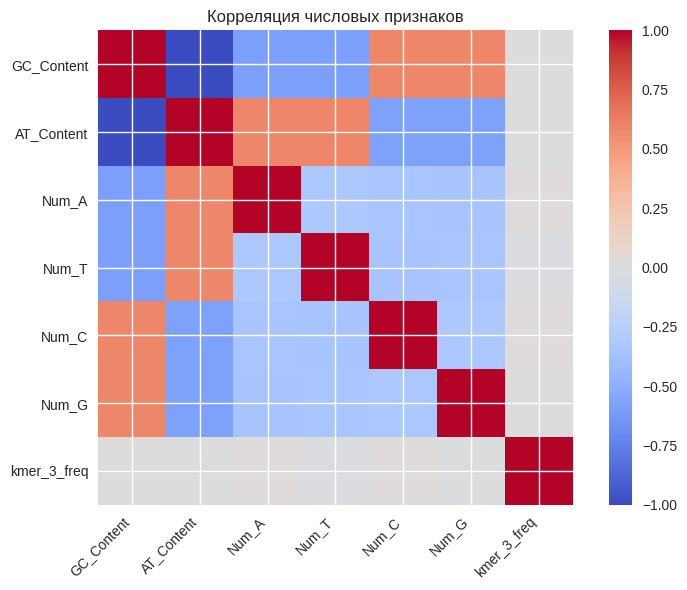

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Выбираем только числовые столбцы для анализа
numeric_cols = ['GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']
df_num = df_clean[numeric_cols]

# 2. Считаем корреляционную матрицу (метод Пирсона)
corr_matrix = df_num.corr()

# 3. Выводим таблицу корреляций
print("Матрица корреляций:")
print(corr_matrix.round(2))

# 4. Строим тепловую карту (Heatmap)
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

In [42]:
# Сохранение очищенного датасета в новый CSV-файл
output_filename = 'synthetic_dna_dataset_cleaned.csv'
df_clean.to_csv(output_filename, index=False)

print(f"Очищенный датасет успешно сохранен в файл: {output_filename}")
print(f"Размер сохраненного файла: {df_clean.shape[0]} строк и {df_clean.shape[1]} столбцов")

Очищенный датасет успешно сохранен в файл: synthetic_dna_dataset_cleaned.csv
Размер сохраненного файла: 3000 строк и 15 столбцов


In [43]:
# 1. Сохранение статистики по типам организмов (Class_Label)
stats_by_class.to_csv('stats_by_class_label.csv', index=True)
print("Сохранено: stats_by_class_label.csv")

# 2. Сохранение статистики по уровню риска (Disease_Risk)
stats_by_risk.to_csv('stats_by_disease_risk.csv', index=True)
print("Сохранено: stats_by_disease_risk.csv")

# 3. Сохранение кросс-таблицы (Организм x Риск)
pivot_table.to_csv('pivot_class_risk_gc_content.csv', index=True)
print("Сохранено: pivot_class_risk_gc_content.csv")

# 4. Сохранение матрицы корреляций числовых признаков
corr_matrix.to_csv('correlation_matrix_numeric.csv', index=True)
print("Сохранено: correlation_matrix_numeric.csv")

Сохранено: stats_by_class_label.csv
Сохранено: stats_by_disease_risk.csv
Сохранено: pivot_class_risk_gc_content.csv
Сохранено: correlation_matrix_numeric.csv


In [44]:
import matplotlib.pyplot as plt

# 1. Гистограмма общего распределения GC-Content
plt.figure(figsize=(10, 6))
plt.hist(df_clean['GC_Content'], bins=30, color='steelblue', edgecolor='black')
mean_val = df_clean['GC_Content'].mean()
median_val = df_clean['GC_Content'].median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {median_val:.2f}')
plt.title('Распределение GC-Content во всем датасете', fontsize=14)
plt.xlabel('GC-Content (%)', fontsize=12)
plt.ylabel('Количество образцов', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('hist_gc_content_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Bar Chart: Средний GC-Content по типам организмов
class_stats = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'std']).reset_index()
plt.figure(figsize=(10, 6))
plt.bar(class_stats['Class_Label'], class_stats['mean'], yerr=class_stats['std'],
        capsize=5, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'], edgecolor='black')
plt.title('Средний GC-Content по типам организмов', fontsize=14)
plt.xlabel('Тип организма', fontsize=12)
plt.ylabel('Средний GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('bar_class_mean_gc.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Boxplot: Распределение GC-Content по классам
data_for_plot = [df_clean[df_clean['Class_Label'] == cls]['GC_Content'].values for cls in df_clean['Class_Label'].unique()]
plt.figure(figsize=(10, 6))
bp = plt.boxplot(data_for_plot, labels=df_clean['Class_Label'].unique(), patch_artist=True)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Распределение GC-Content по типам организмов (Boxplot)', fontsize=14)
plt.xlabel('Тип организма', fontsize=12)
plt.ylabel('GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_class_gc.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Boxplot: Распределение GC-Content по уровню риска
risk_levels = ['Low', 'Medium', 'High']
data_risk = [df_clean[df_clean['Disease_Risk'] == level]['GC_Content'].values for level in risk_levels]
plt.figure(figsize=(10, 6))
bp_risk = plt.boxplot(data_risk, labels=risk_levels, patch_artist=True)
colors_risk = ['#ffcccb', '#add8e6', '#90ee90']
for patch, color in zip(bp_risk['boxes'], colors_risk):
    patch.set_facecolor(color)
plt.title('Распределение GC-Content по уровню риска заболевания', fontsize=14)
plt.xlabel('Уровень риска', fontsize=12)
plt.ylabel('GC-Content (%)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_risk_gc.png', dpi=300, bbox_inches='tight')
plt.close()

print("Графики успешно сохранены в формате PNG.")

/tmp/ipykernel_1261/1654324286.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_stats = df_clean.groupby('Class_Label')['GC_Content'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_1261/1654324286.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_for_plot, labels=df_clean['Class_Label'].unique(), patch_artist=True)
/tmp/ipykernel_1261/1654324286.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_risk = plt.boxplot(data_risk, labels=risk_levels, patch_artist=True)


Графики успешно сохранены в формате PNG.
